# Experiment 6: Singular Value Scaling

Compare PALM and FISTA-PALM on matrices with controlled singular value scales.

**Setup**
- Matrix size: $1000 \times 600$
- Rank: $r = 200$
- Sparsity in $Y$: $25\%$
- Small scales: $10^{-1}$ to $10^{-6}$
- Large scales: $10^{1}$ to $10^{6}$
- Iterations: $100$

**Goal**

Evaluate how sensitive PALM and FISTA-PALM are to the magnitude of the target matrix.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(ROOT))

from src.solvers.palm import PALM
from src.solvers.fista_palm import FISTAPALM

from src.utils.data import create_matrix_with_singular_values, generate_initial_factors
from src.utils.problem_factory import make_matrix_factorisation_problem
from src.utils.plotting import plot_singular_value_scaling_panels
from src.utils.io import make_fig_path, save_table

In [2]:
np.random.seed(42)

m, n, r = 1000, 600, 200
sparsity = 0.25
max_iter = 100
gamma = 1.2

small_scales = [1e-1, 1e-2, 1e-3, 1e-4, 1e-5, 1e-6]
large_scales = [1e1, 1e2, 1e3, 1e4, 1e5, 1e6]
scales = small_scales + large_scales

solvers = {
    "PALM": PALM(max_iter=max_iter),
    "FISTA-PALM": FISTAPALM(max_iter=max_iter),
}

## Run singular value scaling experiment

Generate matrices with fixed singular value scale and record the objective after $100$ iterations.

In [3]:
records = []

for scale in scales:
    A = create_matrix_with_singular_values(
        m, n, r, scale=scale, seed=42
    )

    X0, Y0 = generate_initial_factors(
        m, n, r, seed=42
    )

    problem = make_matrix_factorisation_problem(
        A, r, sparsity, gamma=gamma
    )

    row = {
        "Singular Value Scale": f"{scale:.0e}",
        "Scale": scale,
    }

    for method_name, solver in solvers.items():
        _, _, hist = solver.solve(problem, X0.copy(), Y0.copy())
        row[f"{method_name} Objective @ Iter 100"] = hist[-1]

    records.append(row)

df = pd.DataFrame(records)

## Objective table

Objective values after $100$ iterations for each singular value scale.

In [4]:
params = {
    "m": m,
    "n": n,
    "r": r,
    "s": sparsity,
    "iter": max_iter,
}

save_table(
    df,
    ROOT,
    "singular_value_scaling",
    params,
)

display(
    df.drop(columns=["Scale"]).style
    .set_caption("Objective Values at Iteration 100 for Different Singular Value Scales")
    .format(precision=10)
    .hide(axis="index")
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("text-align", "center"),
                ("font-size", "18px"),
                ("font-weight", "bold"),
            ],
        }
    ])
    .highlight_min(
        subset=[
            "PALM Objective @ Iter 100",
            "FISTA-PALM Objective @ Iter 100",
        ],
        color="lightgreen",
    )
    .set_properties(**{"text-align": "center"})
)

Singular Value Scale,PALM Objective @ Iter 100,FISTA-PALM Objective @ Iter 100
1e-01,181.3762291365,0.9515717967
1e-02,180.3871349225,0.0103508909
1e-03,180.3767082130,0.0009165587
1e-04,180.3765497889,0.0008221752
1e-05,180.3765427866,0.0008213083
1e-06,180.3765421749,0.0008213090
1e+01,9905.1586681799,8715.7907557272
1e+02,913360.9961162981,817950.0373334835
1e+03,85839099.9338791966,80415691.2143037468
1e+04,8559207874.1422367096,8026059701.9546985626


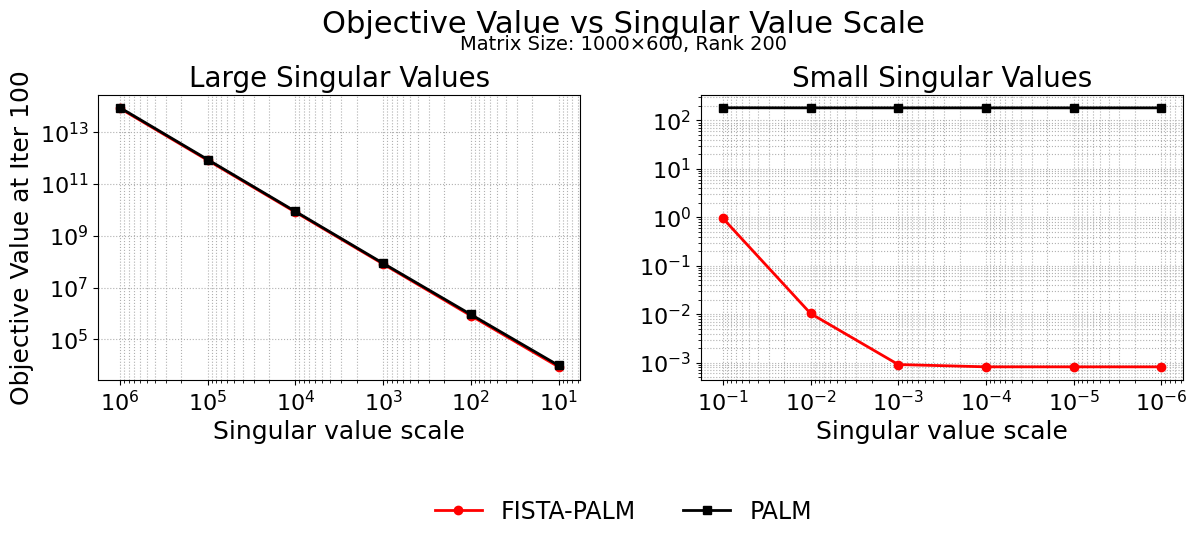

In [5]:
plot_singular_value_scaling_panels(
    df.melt(
        id_vars=["Scale", "Singular Value Scale"],
        value_vars=[
            "PALM Objective @ Iter 100",
            "FISTA-PALM Objective @ Iter 100",
        ],
        var_name="Method",
        value_name="Final Objective",
    ).assign(
        Method=lambda d: d["Method"].str.replace(" Objective @ Iter 100", "", regex=False)
    ),
    small_scales=small_scales,
    large_scales=large_scales,
    title="Objective Value vs Singular Value Scale",
    subtitle=f"Matrix Size: {m}×{n}, Rank {r}",
    save_path=make_fig_path(ROOT, "singular_value_scaling", params),
)

## Observations

- For large singular value scales ($10^1$–$10^6$), both PALM and FISTA-PALM exhibit similar behaviour, with objective values scaling proportionally with the magnitude of the matrix.
- In this regime, the optimisation difficulty is dominated by scale rather than algorithmic differences, leading to nearly identical convergence outcomes.

- For small singular value scales ($10^{-1}$–$10^{-6}$), a clear difference emerges:
  - PALM stagnates at a relatively high objective value and shows little sensitivity to further decreases in scale.
  - FISTA-PALM continues to reduce the objective significantly, achieving much lower values.

- This indicates that FISTA-PALM is more robust to low-magnitude regimes, where gradients become small and standard PALM updates struggle to make progress.

- Overall, the experiment shows that:
  - Scaling the problem uniformly does not inherently favour either method at large magnitudes
  - However, in low-signal regimes, FISTA-PALM maintains effective updates while PALM effectively stalls

- The separation between the two methods is therefore not driven by scale alone, but by how each method handles diminishing gradient information.